In [14]:
## ==================================================
# Your Project
# ==================================================

# Team Members:
# 1) Mariam Elsayed
# 2) Mariam Mahrous
# 3) Mostafa Ahmed

# Project Name:
# Book Recommendation Data Analysis Project
#################################################################################################################################
                                  #Name: Book Recommendation Data Analysis Project.
#=> Data Loading and Understanding Data.
#=> In this section we will import the required libraries load the datasets and explore the structure of the data.
#################################################################################################################################
# Import the required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset
#=>The dataset contains three CSV files:
#=> Books.csv: Contains information about books.
#=> Ratings.csv: Contains users' ratings for books.
#=> Users.csv: Contains information about users.

# Load the CSV files into Pandas DataFrames
books = pd.read_csv("Books.csv", low_memory=False)
ratings = pd.read_csv("Ratings.csv")
users = pd.read_csv("Users.csv")

#=> Exploring the Dataset

# Display the first 5 rows of the Books dataset
books.head()

# Display the last 5 rows of the Books dataset
books.tail()

# Get the number of rows and columns in the Books dataset
books.shape

# Display the column names of the Books dataset
books.columns

# Display the data types of each column in the Books dataset
books.dtypes

# Display information about the Books dataset
books.info()

# Merge ratings data with books data using ISBN
books_ratings = pd.merge(ratings, books, on="ISBN")

# Display the first 5 rows of the merged dataset
books_ratings.head()

# Merge the dataset with users data using User-ID
final_data = pd.merge(books_ratings, users, on="User-ID")

# Display the first 5 rows of the final dataset
final_data.head()

# Save the final merged dataset as a CSV file
final_data.to_csv("final_book_dataset.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0


In [15]:
#################################################################################################################################
                                            # Data Cleaning and Analysis
#=> Data Cleaning and Analysis.
#=> In this section we will clean the dataset by handling missing values,
#=> perform statistical analysis, sort and filter the data, create new features
#and prepare the cleaned dataset for further analysis and visualization.
#################################################################################################################################

# Fill missing values in Age column with 0
final_data["Age"] = final_data["Age"].fillna(0)

# Remove rows that contain missing values
final_data = final_data.dropna()

# Display statistics for numeric columns
print("Dataset Statistics:")
print(final_data.describe())

# Sort the dataset by Book Rating in descending order
sorted_data = final_data.sort_values(by="Book-Rating", ascending=False)

# Display the first 5 rows after sorting
print("\nTop Rated Books:")
print(sorted_data.head())

# Create Age Group column
final_data["Age_Group"] = final_data["Age"].apply(
    lambda x: "Unknown" if x == 0
    else "Young" if x < 30
    else "Adult"
)
# Create a new column by multiplying two numeric columns
final_data["Age_x_Rating"] = final_data["Age"] * final_data["Book-Rating"]

# Users older than 25 years
adult_users = final_data[final_data["Age"] > 25]

# Ratings greater than or equal to 8
high_ratings = final_data[final_data["Book-Rating"] >= 8]

print("\nNumber of users older than 25:", len(adult_users))
print("Number of ratings >= 8:", len(high_ratings))

# Convert Age_Group column to category type
final_data["Age_Group"] = final_data["Age_Group"].astype("category")

# Mean and Standard Deviation
age_mean = final_data["Age"].mean()
age_std = final_data["Age"].std()

rating_mean = final_data["Book-Rating"].mean()
rating_std = final_data["Book-Rating"].std()

print("\nMean Age:", age_mean)
print("Age Standard Deviation:", age_std)

print("\nMean Rating:", rating_mean)
print("Rating Standard Deviation:", rating_std)

# Square the book ratings
final_data["Rating_Squared"] = final_data["Book-Rating"] ** 2

# Count ratings greater than or equal to 5
high_count = (final_data["Book-Rating"] >= 5).sum()

# Count ratings less than 5
low_count = (final_data["Book-Rating"] < 5).sum()

print("\nRatings >= 5:", high_count)
print("Ratings < 5:", low_count)

# Save the cleaned dataset
final_data.to_csv("final_book_dataset_cleaned.csv", index=False)
print("\nCleaned dataset saved successfully.") 

Dataset Statistics:
            User-ID   Book-Rating           Age
count  1.031128e+06  1.031128e+06  1.031128e+06
mean   1.405946e+05  2.839032e+00  2.732103e+01
std    8.052485e+04  3.854147e+00  2.050634e+01
min    2.000000e+00  0.000000e+00  0.000000e+00
25%    7.041500e+04  0.000000e+00  0.000000e+00
50%    1.412100e+05  0.000000e+00  3.000000e+01
75%    2.114260e+05  7.000000e+00  4.100000e+01
max    2.788540e+05  1.000000e+01  2.440000e+02

Top Rated Books:
         User-ID        ISBN  Book-Rating                   Book-Title  \
1031135   276721  0590442449           10            Fourth Grade Rats   
880845    236283  0316150363           10         Dogs and Their Women   
880805    236283  0307213552           10     Baby animals on the farm   
880808    236283  030723116X           10  Early Bird on Sesame Street   
243739     63574  1861470460           10  The Impressionists Handbook   

            Book-Author Year-Of-Publication  \
1031135  Jerry Spinelli               

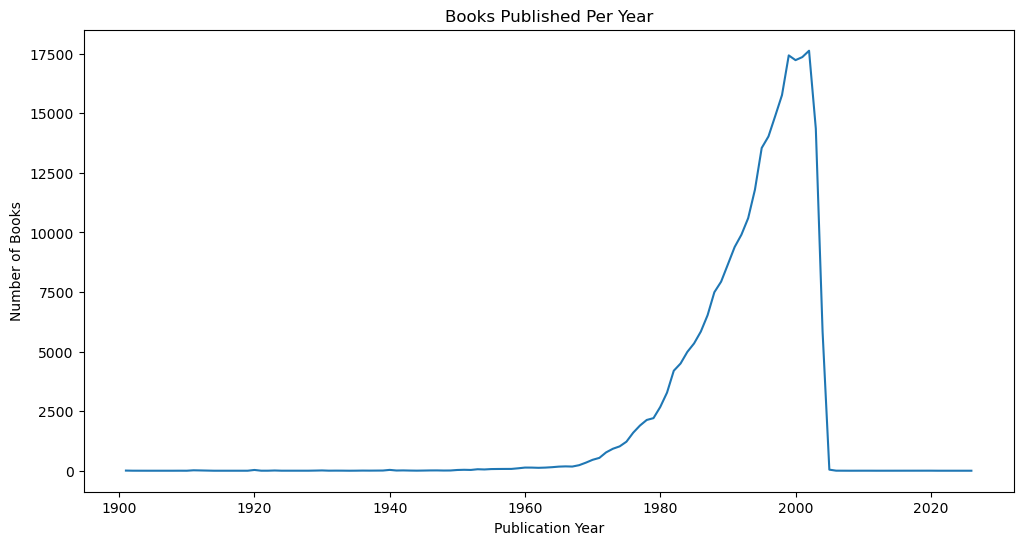

In [20]:
#################################################################################################################################
                                            # Data Visualization
#=> Data Visualization.
#=> In this section we will visualize the dataset using different charts
#=> to explore patterns, trends, and relationships between variables.
#=> These visualizations help us better understand the data and support our analysis.
#################################################################################################################################
#1)                                 &Line Plot: Books Published Per Year.%
# Remove invalid publication years
books = books[books["Year-Of-Publication"] != "DK Publishing Inc"]
books = books[books["Year-Of-Publication"] != "Gallimard"]

# Convert publication year to numeric
books["Year-Of-Publication"] = pd.to_numeric(
    books["Year-Of-Publication"],
    errors="coerce"
)
# Remove missing values
books = books.dropna(subset=["Year-Of-Publication"])

# Count books per year and sort by year
year = books["Year-Of-Publication"].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(year.index, year.values)
plt.title("Books Published Per Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Books")
plt.show()

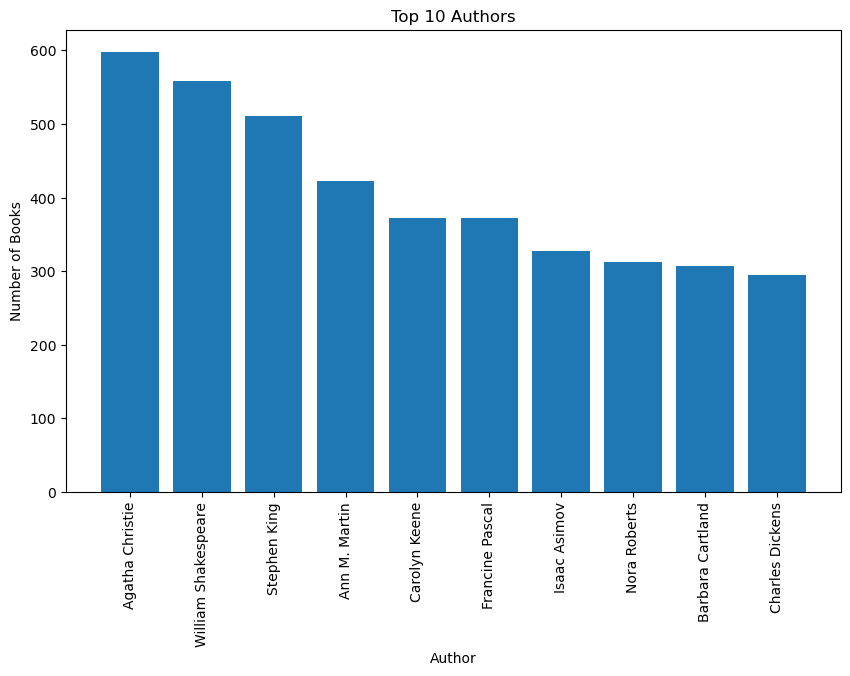

In [21]:
#2)                                             &Bar Chart: Top 10 Authors.&
# Count the top 10 authors with the most books
author = books["Book-Author"].value_counts().head(10)

# X-axis: Author names
x = author.index

# Y-axis: Number of books
y = author.values

# Create the bar chart
plt.figure(figsize=(10,6))
plt.bar(x, y)

# Add title and labels
plt.title("Top 10 Authors")
plt.xlabel("Author")
plt.ylabel("Number of Books")

# Rotate author names for better readability
plt.xticks(rotation=90)

# Display the chart
plt.show()

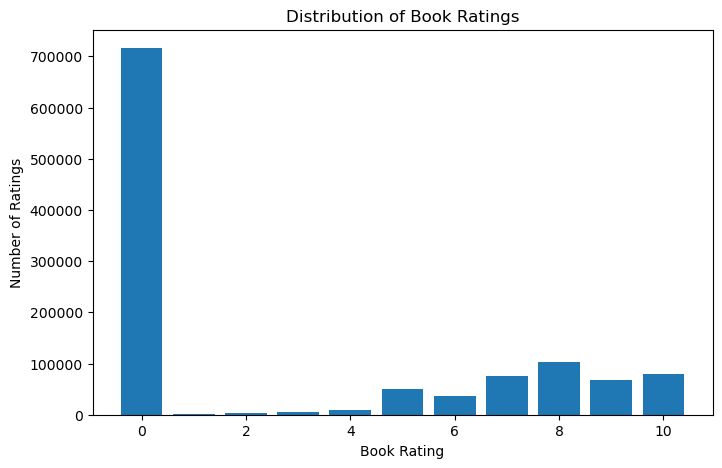

In [22]:
#3)                                        &Bar Chart: Distribution of Book Ratings.&
# Count the frequency of each book rating
rate = ratings["Book-Rating"].value_counts().sort_index()

# X-axis: Rating values
x = rate.index

# Y-axis: Number of ratings
y = rate.values

# Create the bar chart
plt.figure(figsize=(8,5))
plt.bar(x, y)

# Add title and labels
plt.title("Distribution of Book Ratings")
plt.xlabel("Book Rating")
plt.ylabel("Number of Ratings")

plt.show()

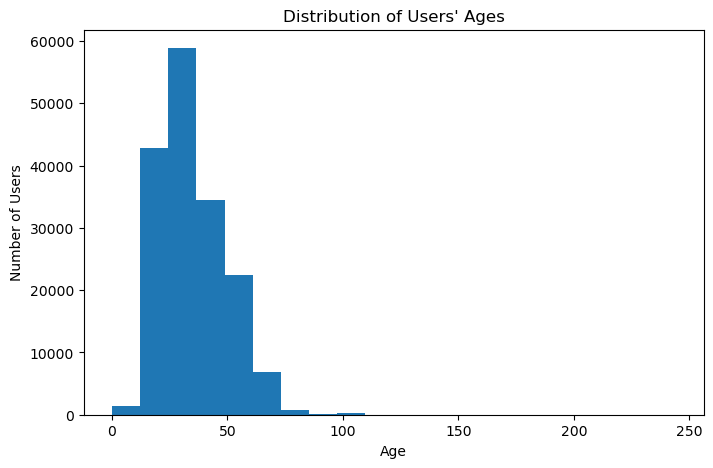

In [23]:
#4)                                        &Distribution of Users' Ages (Histogram)ز&
# Remove missing values from Age column
age = users["Age"].dropna()

# Create a histogram for users' ages
plt.figure(figsize=(8,5))
plt.hist(age, bins=20)

# Add title and labels
plt.title("Distribution of Users' Ages")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.show()

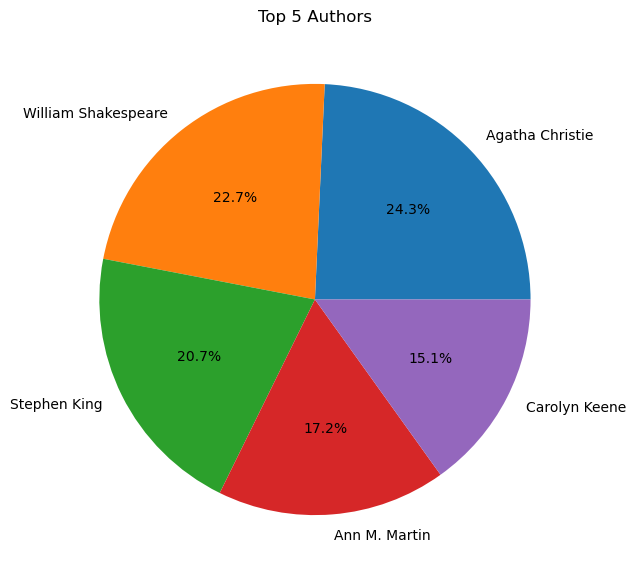

In [24]:
#5)                                   &Pie Chart → Top 5 Authors&
# Get the top 5 authors with the highest number of books
author = books["Book-Author"].value_counts().head(5)

# Create a pie chart
plt.figure(figsize=(7,7))
plt.pie(author.values, labels=author.index, autopct="%1.1f%%")

# Add chart title
plt.title("Top 5 Authors")

# Display the chart
plt.show()

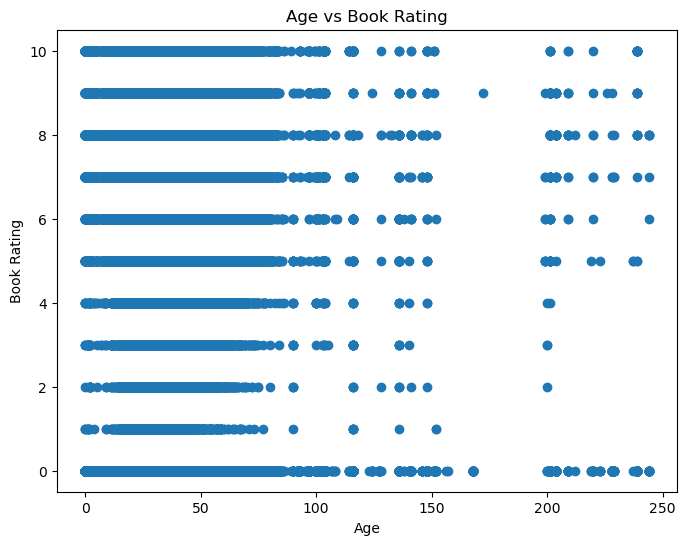

In [25]:
#6)                              &Scatter Plot → Age vs Book Rating.&
# Merge users and ratings datasets using User-ID
merge_data = pd.merge(users, ratings, on="User-ID")

# Remove rows with missing Age values
merge_data = merge_data.dropna(subset=["Age"])

# Create a scatter plot
plt.figure(figsize=(8,6))
plt.scatter(merge_data["Age"], merge_data["Book-Rating"])

# Add title and labels
plt.title("Age vs Book Rating")
plt.xlabel("Age")
plt.ylabel("Book Rating")

# Display the chart
plt.show()

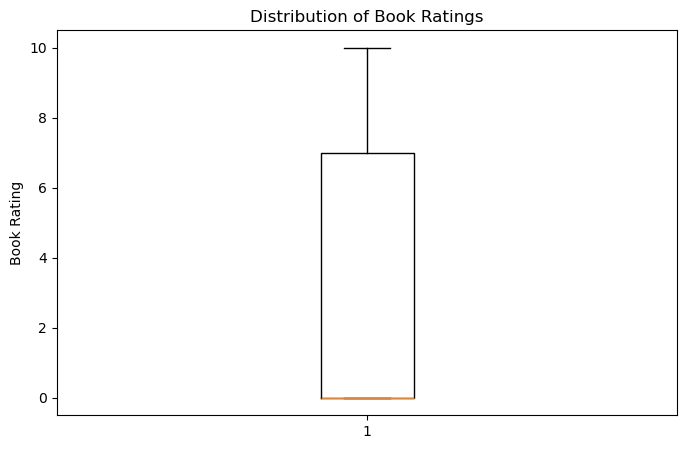

In [26]:
#7)                                 &Box Plot → Distribution of Book Ratings.&
# Create a box plot for book ratings
plt.figure(figsize=(8,5))

plt.boxplot(ratings["Book-Rating"])

# Add title and labels
plt.title("Distribution of Book Ratings")
plt.ylabel("Book Rating")

# Display the chart
plt.show()

In [ ]:
####################################################### =>THANKS<= ######################################################################